In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
from xgboost import XGBClassifier

# If xgboost not installed, run this first:
# !pip install xgboost

In [2]:
# Load Titanic dataset directly from URL
url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
df = pd.read_csv(url)

print("Shape:", df.shape)
print("\nFirst 5 rows:")
df.head()

Shape: (891, 12)

First 5 rows:


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [3]:
print("Columns:", df.columns.tolist())
print("\nMissing values:")
print(df.isnull().sum())
print("\nData types:")
print(df.dtypes)
print("\nSurvived breakdown:")
print(df['Survived'].value_counts())

Columns: ['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked']

Missing values:
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

Data types:
PassengerId      int64
Survived         int64
Pclass           int64
Name               str
Sex                str
Age            float64
SibSp            int64
Parch            int64
Ticket             str
Fare           float64
Cabin              str
Embarked           str
dtype: object

Survived breakdown:
Survived
0    549
1    342
Name: count, dtype: int64


In [14]:
# Work on a copy so original stays safe
data = df.copy()

# ── FEATURE 1: Title from name ──────────────────────────────────────
data['Title'] = data['Name'].str.extract(r' ([A-Za-z]+)\.', expand=False)

data['Title'] = data['Title'].replace(
    ['Lady','Countess','Capt','Col','Don','Dr','Major','Rev','Sir','Jonkheer','Dona'],
    'Rare'
)
data['Title'] = data['Title'].replace({'Mlle':'Miss', 'Ms':'Miss', 'Mme':'Mrs'})

print("Titles found:", data['Title'].value_counts().to_dict())

# ── FEATURE 2: Family size ───────────────────────────────────────────
data['FamilySize'] = data['SibSp'] + data['Parch'] + 1
data['IsAlone'] = (data['FamilySize'] == 1).astype(int)

# ── FEATURE 3: Fill missing age with median by title ─────────────────
age_medians = data.groupby('Title')['Age'].median()
data['Age'] = data.apply(
    lambda row: age_medians[row['Title']] if pd.isnull(row['Age']) else row['Age'],
    axis=1
)

# ── FEATURE 4: Age bands ─────────────────────────────────────────────
data['AgeBand'] = pd.cut(data['Age'], bins=[0,12,18,35,60,100],
                          labels=['Child','Teen','YoungAdult','Adult','Senior'])

# ── FEATURE 5: Fare bands ─────────────────────────────────────────── 
# FIX: assign directly instead of inplace=True
data['Fare'] = data['Fare'].fillna(data['Fare'].median())
data['FareBand'] = pd.qcut(data['Fare'], q=4, labels=['Low','Medium','High','VeryHigh'])

# ── FEATURE 6: Deck from cabin number ────────────────────────────────
data['Deck'] = data['Cabin'].str[0]
# FIX: assign directly instead of inplace=True
data['Deck'] = data['Deck'].fillna('Unknown')

# ── Fix Embarked missing values ──────────────────────────────────────
# FIX: assign directly instead of inplace=True
data['Embarked'] = data['Embarked'].fillna(data['Embarked'].mode()[0])

print("\nNew features created:")
print(data[['Title','FamilySize','IsAlone','AgeBand','FareBand','Deck']].head(10))# ML models need numbers — convert all categorical columns

# Title → number
title_map = {'Mr':1, 'Miss':2, 'Mrs':3, 'Master':4, 'Rare':5}
data['Title'] = data['Title'].map(title_map)

# Sex → number
data['Sex'] = data['Sex'].map({'male':0, 'female':1})

# Embarked → number
data['Embarked'] = data['Embarked'].map({'S':0, 'C':1, 'Q':2})

# AgeBand → number
data['AgeBand'] = data['AgeBand'].map(
    {'Child':0, 'Teen':1, 'YoungAdult':2, 'Adult':3, 'Senior':4}
)

# FareBand → number
data['FareBand'] = data['FareBand'].map(
    {'Low':0, 'Medium':1, 'High':2, 'VeryHigh':3}
)

# Deck → number
deck_map = {d:i for i,d in enumerate(data['Deck'].unique())}
data['Deck'] = data['Deck'].map(deck_map)

print("All columns now numeric:")
print(data.dtypes)

Titles found: {'Mr': 517, 'Miss': 185, 'Mrs': 126, 'Master': 40, 'Rare': 23}

New features created:
    Title  FamilySize  IsAlone     AgeBand  FareBand     Deck
0      Mr           2        0  YoungAdult       Low  Unknown
1     Mrs           2        0       Adult  VeryHigh        C
2    Miss           1        1  YoungAdult    Medium  Unknown
3     Mrs           2        0  YoungAdult  VeryHigh        C
4      Mr           1        1  YoungAdult    Medium  Unknown
5      Mr           1        1  YoungAdult    Medium  Unknown
6      Mr           1        1       Adult  VeryHigh        E
7  Master           5        0       Child      High  Unknown
8     Mrs           3        0  YoungAdult    Medium  Unknown
9     Mrs           2        0        Teen      High  Unknown
All columns now numeric:
PassengerId       int64
Survived          int64
Pclass            int64
Name                str
Sex               int64
Age             float64
SibSp             int64
Parch             int64
T

In [11]:
# Pick our features — drop columns that are useless or leaky
features = ['Pclass','Sex','Age','SibSp','Parch','Fare',
            'Embarked','Title','FamilySize','IsAlone',
            'AgeBand','FareBand','Deck']

X = data[features].copy()
y = data['Survived']

# FIX: convert any remaining category columns to int
# pd.cut and pd.qcut create 'category' dtype which XGBoost can't handle
for col in X.columns:
    if X[col].dtype.name == 'category':
        X[col] = X[col].astype(int)

# Double check — all columns should be numeric now
print("Column dtypes after fix:")
print(X.dtypes)
print("\nAny remaining non-numeric?", X.select_dtypes(exclude='number').columns.tolist())

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"\nTraining samples : {X_train.shape[0]}")
print(f"Test samples     : {X_test.shape[0]}")
print(f"Features used    : {X_train.shape[1]}")

Column dtypes after fix:
Pclass          int64
Sex             int64
Age           float64
SibSp           int64
Parch           int64
Fare          float64
Embarked        int64
Title           int64
FamilySize      int64
IsAlone         int64
AgeBand         int64
FareBand        int64
Deck            int64
dtype: object

Any remaining non-numeric? []

Training samples : 712
Test samples     : 179
Features used    : 13


In [7]:
# Pick our features — drop columns that are useless or leaky
features = ['Pclass','Sex','Age','SibSp','Parch','Fare',
            'Embarked','Title','FamilySize','IsAlone',
            'AgeBand','FareBand','Deck']

X = data[features]
y = data['Survived']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training samples : {X_train.shape[0]}")
print(f"Test samples     : {X_test.shape[0]}")
print(f"Features used    : {X_train.shape[1]}")

Training samples : 712
Test samples     : 179
Features used    : 13


In [13]:
rf = RandomForestClassifier(
    n_estimators=100,
    max_depth=6,
    random_state=42
)
rf.fit(X_train, y_train)
rf_preds = rf.predict(X_test)

rf_acc = accuracy_score(y_test, rf_preds)
print(f"Random Forest Accuracy: {rf_acc:.4f}")
print(classification_report(y_test, rf_preds))

Random Forest Accuracy: 0.8156
              precision    recall  f1-score   support

           0       0.83      0.87      0.85       110
           1       0.78      0.72      0.75        69

    accuracy                           0.82       179
   macro avg       0.81      0.80      0.80       179
weighted avg       0.81      0.82      0.81       179



In [12]:
xgb = XGBClassifier(
    n_estimators=100,    # 100 boosting rounds
    learning_rate=0.1,   # small corrections each round
    max_depth=4,         # shallow trees (prevents overfitting)
    subsample=0.8,       # use 80% of rows per tree
    colsample_bytree=0.8,# use 80% of features per tree
    random_state=42,
    eval_metric='logloss',
    verbosity=0
)
xgb.fit(X_train, y_train)
xgb_preds = xgb.predict(X_test)

xgb_acc = accuracy_score(y_test, xgb_preds)
print(f"XGBoost Accuracy: {xgb_acc:.4f}")
print(classification_report(y_test, xgb_preds))

XGBoost Accuracy: 0.8045
              precision    recall  f1-score   support

           0       0.81      0.89      0.85       110
           1       0.79      0.67      0.72        69

    accuracy                           0.80       179
   macro avg       0.80      0.78      0.79       179
weighted avg       0.80      0.80      0.80       179



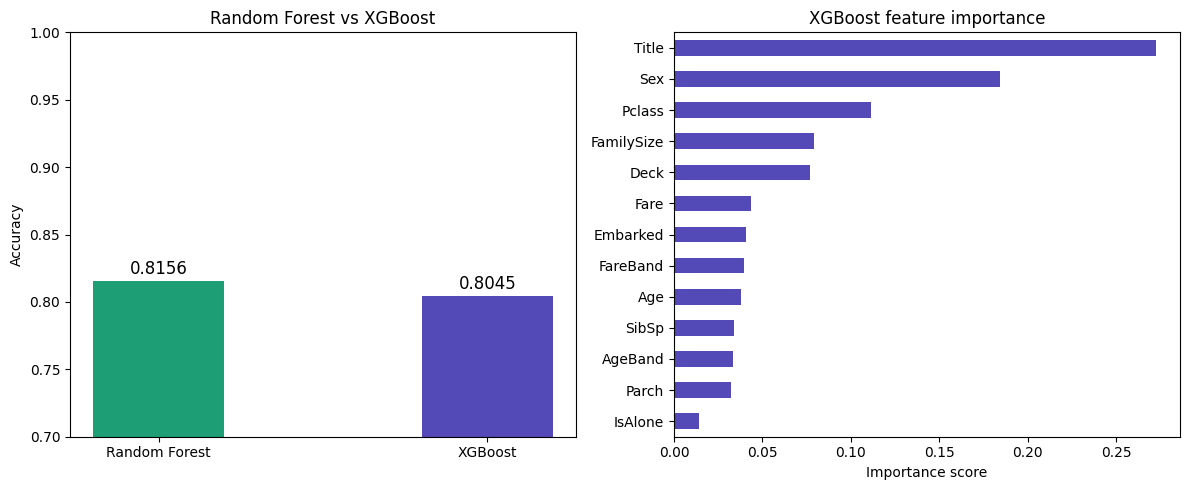


Random Forest : 0.8156
XGBoost       : 0.8045
XGBoost wins by: -1.12%


In [15]:
plt.figure(figsize=(12, 5))

# Left — accuracy comparison
plt.subplot(1, 2, 1)
models = ['Random Forest', 'XGBoost']
scores = [rf_acc, xgb_acc]
colors = ['#1D9E75', '#534AB7']
bars = plt.bar(models, scores, color=colors, width=0.4)
plt.ylim(0.7, 1.0)
plt.ylabel('Accuracy')
plt.title('Random Forest vs XGBoost')
for bar, score in zip(bars, scores):
    plt.text(bar.get_x()+bar.get_width()/2,
             bar.get_height()+0.005,
             f'{score:.4f}', ha='center', fontsize=12)

# Right — XGBoost feature importance
plt.subplot(1, 2, 2)
importances = pd.Series(xgb.feature_importances_, index=features)
importances.sort_values().plot(kind='barh', color='#534AB7')
plt.title('XGBoost feature importance')
plt.xlabel('Importance score')

plt.tight_layout()
plt.show()

print(f"\nRandom Forest : {rf_acc:.4f}")
print(f"XGBoost       : {xgb_acc:.4f}")
print(f"XGBoost wins by: {(xgb_acc - rf_acc)*100:.2f}%")

In [16]:
# Train XGBoost WITHOUT our engineered features to show the difference
X_basic = data[['Pclass','Sex','Age','SibSp','Parch','Fare','Embarked']]

X_train_b, X_test_b, y_train_b, y_test_b = train_test_split(
    X_basic, y, test_size=0.2, random_state=42, stratify=y
)

xgb_basic = XGBClassifier(
    n_estimators=100, learning_rate=0.1,
    max_depth=4, random_state=42,
    eval_metric='logloss', verbosity=0
)
xgb_basic.fit(X_train_b, y_train_b)
basic_acc = accuracy_score(y_test_b, xgb_basic.predict(X_test_b))

print("=" * 45)
print(f"XGBoost WITHOUT feature engineering: {basic_acc:.4f}")
print(f"XGBoost WITH    feature engineering: {xgb_acc:.4f}")
print(f"Improvement from engineering       : +{(xgb_acc-basic_acc)*100:.2f}%")
print("=" * 45)
print("\nThis proves feature engineering matters more than model choice!")

XGBoost WITHOUT feature engineering: 0.7989
XGBoost WITH    feature engineering: 0.8045
Improvement from engineering       : +0.56%

This proves feature engineering matters more than model choice!


Method                   Mean      Std      Min      Max
K-Fold                 0.8182   0.0213   0.7865   0.8483
Stratified K-Fold      0.8159   0.0133   0.7978   0.8380


/var/folders/4w/0wgb9g4x62d5l57bc0x5ngt80000gn/T/ipykernel_49820/4267313320.py:38: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([kf_scores, skf_scores], labels=['K-Fold', 'Stratified'])


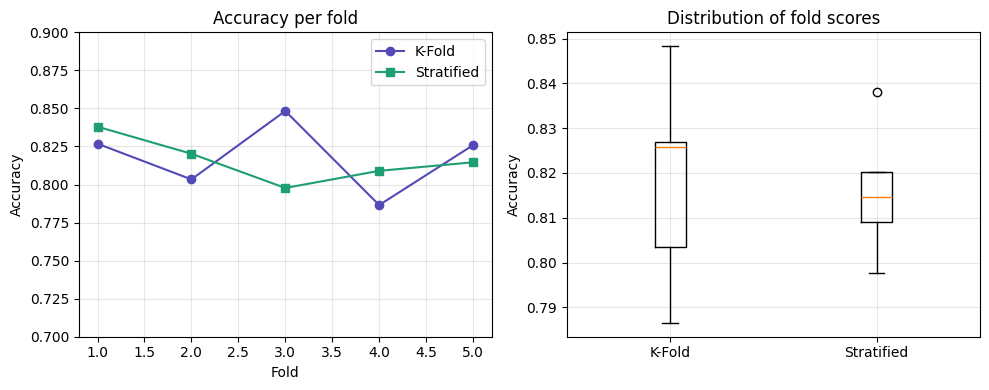

In [17]:
from sklearn.model_selection import (KFold, StratifiedKFold,
                                      TimeSeriesSplit, cross_val_score)

model = RandomForestClassifier(n_estimators=100, random_state=42)

# 1. Regular K-Fold
kf = KFold(n_splits=5, shuffle=True, random_state=42)
kf_scores = cross_val_score(model, X, y, cv=kf, scoring='accuracy')

# 2. Stratified K-Fold
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
skf_scores = cross_val_score(model, X, y, cv=skf, scoring='accuracy')

# Print comparison
print("=" * 50)
print(f"{'Method':<20} {'Mean':>8} {'Std':>8} {'Min':>8} {'Max':>8}")
print("=" * 50)
print(f"{'K-Fold':<20} {kf_scores.mean():>8.4f} {kf_scores.std():>8.4f} "
      f"{kf_scores.min():>8.4f} {kf_scores.max():>8.4f}")
print(f"{'Stratified K-Fold':<20} {skf_scores.mean():>8.4f} {skf_scores.std():>8.4f} "
      f"{skf_scores.min():>8.4f} {skf_scores.max():>8.4f}")
print("=" * 50)

# Visualize
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.plot(range(1,6), kf_scores,  'o-', color='#534AB7', label='K-Fold')
plt.plot(range(1,6), skf_scores, 's-', color='#1D9E75', label='Stratified')
plt.xlabel('Fold')
plt.ylabel('Accuracy')
plt.title('Accuracy per fold')
plt.legend()
plt.ylim(0.7, 0.9)
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.boxplot([kf_scores, skf_scores], labels=['K-Fold', 'Stratified'])
plt.ylabel('Accuracy')
plt.title('Distribution of fold scores')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()